In [1]:
# Imports
import torch
import torchvision
import transformers
import sys
from transformers import AutoProcessor
from transformers import CLIPModel
import pandas as pd
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

%load_ext autoreload
%autoreload 2
import embeddings as em

/Users/mds/Documents/MSc/10_Project/product-sales/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Record versions
print("Python version: ", sys.version)
print("PyTorch version: ", torch.__version__)
print("torchvision version: ", torchvision.__version__)
print("Transformers version: ", transformers.__version__)

x = torch.rand(5, 3)
print(x)

processor = AutoProcessor.from_pretrained("openai/clip-vit-large-patch14")
print(processor)

Python version:  3.10.11 (v3.10.11:7d4cc5aa85, Apr  4 2023, 19:05:19) [Clang 13.0.0 (clang-1300.0.29.30)]
PyTorch version:  2.13.0
torchvision version:  0.28.0
Transformers version:  5.15.1
tensor([[0.9321, 0.1534, 0.0036],
        [0.6054, 0.7306, 0.2752],
        [0.1427, 0.1862, 0.8596],
        [0.4360, 0.2570, 0.2448],
        [0.8462, 0.6487, 0.4140]])


CLIPProcessor:
- image_processor: CLIPImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

- tokenizer: CLIPTokenizer(name_or_path='openai/clip-vit-large-patch14', vocab_size=49408, model_max_length=77, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip

Check that CLIP's resize target matches the crop size, so that the images don't lose any of their edges after they're made square.

In [3]:
processor.image_processor.size

SizeDict(height=None, width=None, longest_edge=None, shortest_edge=224, max_height=None, max_width=None)

In [4]:
if torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

Load CLIP model

In [5]:
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
model.to(device)
model.eval()

print(model.config.projection_dim)
print(next(model.parameters()).device)

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 5996.86it/s]


768
mps:0


Test on 10 products.
- some random
- some low res samples

In [6]:
df = pd.read_csv('data/train_with_target.csv', usecols=['external_code', 'image_path', 'category', 'color', 'fabric'])

df_img = pd.read_csv('data/image_meta.csv', usecols=['external_code', 'w', 'h', 'low_res'])

path = kagglehub.dataset_download("konradb/visuelle-complete-dataset")
image_root = Path(path) / 'images'

pick_sample = df.merge(df_img, on='external_code', how='inner')

# Two samples that are low res
lowres_sample = pick_sample[pick_sample['low_res'] == True].head(3)['external_code'].tolist()

# Four random ones
random_sample = pick_sample.sample(7, random_state=7)['external_code'].tolist()

collected_sample = lowres_sample + random_sample
collected_sample = list(dict.fromkeys(collected_sample))

trial_df = df[df['external_code'].isin(collected_sample)].copy()

print(trial_df.merge(df_img, on='external_code')[
    ['external_code', 'category', 'w', 'h', 'low_res']
])

   external_code       category    w    h  low_res
0            450      patterned  304  401    False
1           1078       culottes  202  180     True
2           1215       culottes   58  160     True
3           1733    long sleeve  516  476    False
4           1824    long sleeve  217  213     True
5           2154    shirt dress  835  894    False
6           2513  solid colours  594  898    False
7           2844     long dress  205  452    False
8           3891    long sleeve  896  781    False
9           4452  short sleeves  890  804    False


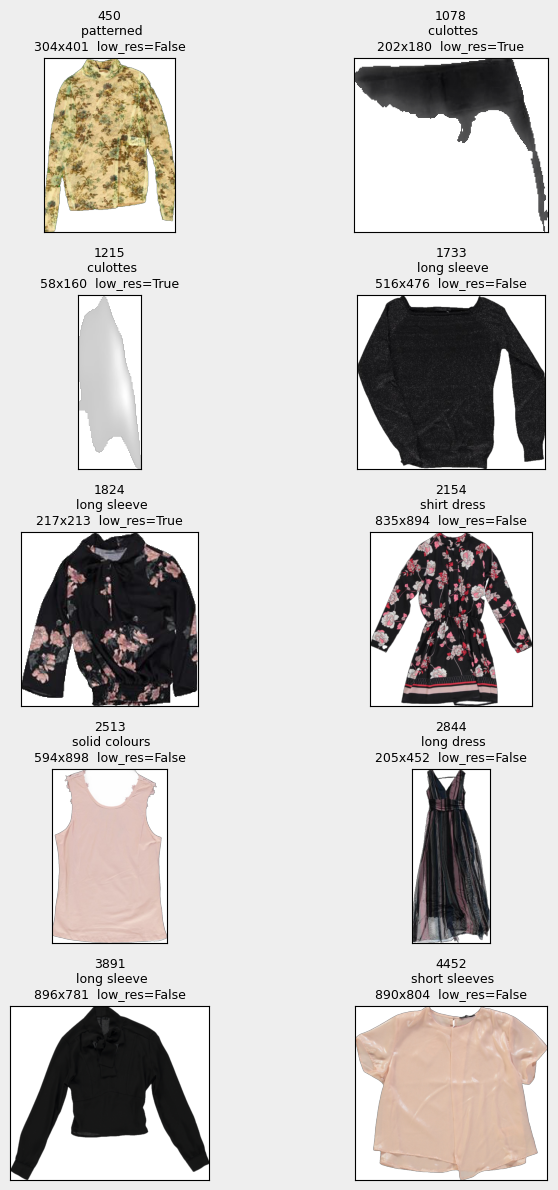

In [7]:
# print matplot lib grid with the images of the 10 products 
# to visually check before going further

display_df = trial_df.merge(df_img, on='external_code').reset_index(drop=True)

fig, axes = plt.subplots(5, 2, figsize=(8, 12))
fig.patch.set_facecolor('#EEE')

for ax, row in zip(axes.ravel(), display_df.itertuples()):
    img = Image.open(image_root / row.image_path)
    assert img.size == (row.w, row.h)          # meta agrees with disk
    ax.imshow(img)
    ax.set_title(
        f"{row.external_code}\n {row.category}\n"
        f"{row.w}x{row.h}  low_res={row.low_res}",
        fontsize=9,
    )
    ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
plt.show()

Test the embedding functions

In [8]:
# test the text builder
df_train = pd.read_csv('data/train_with_target.csv', usecols=['external_code', 'image_path', 'category', 'color', 'fabric'])
df_test = pd.read_csv('data/test_with_target.csv', usecols=['external_code', 'image_path', 'category', 'color', 'fabric'])

df = pd.concat([df_train, df_test], ignore_index=True)

assert df['external_code'].nunique() == 5577

df_with_text = em.build_text_feature(df)

df_with_text['text'].head(20)


0       long sleeve, yellow, acrylic
1        long sleeve, brown, acrylic
2        culottes, blue, scuba crepe
3       long sleeve, yellow, acrylic
4         long sleeve, grey, acrylic
5         long sleeve, grey, acrylic
6        long sleeve, brown, acrylic
7        long sleeve, green, acrylic
8        culottes, blue, scuba crepe
9            miniskirt, black, tulle
10      short sleeves, green, angora
11       long sleeve, green, acrylic
12       long sleeve, green, acrylic
13     short sleeves, yellow, angora
14      short sleeves, green, angora
15             printed, brown, tulle
16        short sleeves, red, angora
17    short cardigan, yellow, angora
18       short cardigan, red, angora
19      long sleeve, yellow, acrylic
Name: text, dtype: object

In [9]:
# quick ref of what's above
# model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
# processor = AutoProcessor.from_pretrained("openai/clip-vit-large-patch14")

text_vectors_test = em.encode_text(df_with_text.head(10), model, processor, device, 8)

print(next(model.parameters()).device)
print(text_vectors_test.shape)

mps:0
(10, 769)


In [10]:
# full run of products
text_vectors = em.encode_text(df_with_text, model, processor, device, 256)

print(text_vectors.shape)

text_vectors.to_parquet('data/clip_text.parquet', index=False)

(5577, 769)


In [ ]:
# test encode_images
image_vectors_test = em.encode_images(df.head(10), model, processor, device, 10, image_root)

print(image_vectors_test.shape)


(10, 769)


In [ ]:
# check how long it would take to encode the images for encoding the images
import time

_ = em.encode_images(df.head(16), model, processor, device, 16, image_root)

start = time.time()

_ = em.encode_images(df.head(64), model, processor, device, 16, image_root)
elapsed = time.time() - start

print(elapsed, elapsed / 64 * 5577 / 60, "minutes")

10.474722146987915 15.21289724316448 minutes


In [ ]:
image_vectors = em.encode_images(df, model, processor, device, 16, image_root)

print(image_vectors.shape)
image_vectors.to_parquet('data/clip_image.parquet', index=False)